In [1]:
import numpy as np
import getdist
import utils
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

chain_gr = utils.load_chain(48)
chain_mg = utils.load_chain(56)

In [2]:
chi2_cmb_gr = chain_gr['chi2__planck_2020_hillipop.TTTEEE'] + chain_gr['chi2__planck_2018_lowl.TT'] + chain_gr['chi2__planck_2020_lollipop.lowlEB']
chi2_cmb_mg = chain_mg['chi2__planck_2020_hillipop.TTTEEE'] + chain_mg['chi2__planck_2018_lowl.TT'] + chain_mg['chi2__planck_2020_lollipop.lowlEB']

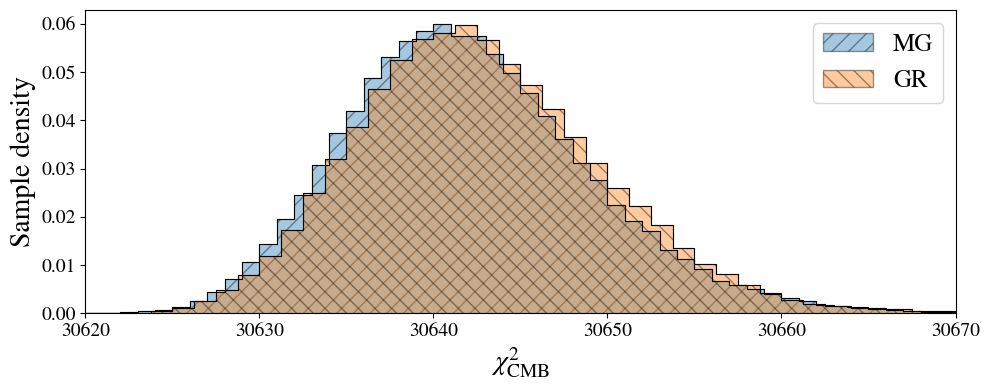

In [18]:
# Set up a wider figure and larger font sizes for readability
fig, ax = plt.subplots(figsize=(10,4))
counts_mg, bins_mg = np.histogram(chi2_cmb_mg, bins=50, range=[30620, 30670], density=True)
# Create step-wise coordinates for a single filled polygon
x_mg = np.repeat(bins_mg, 2)[1:-1]
y_mg = np.repeat(counts_mg, 2)
ax.fill_between(x_mg, y_mg, facecolor='C0', alpha=0.4, hatch='//', edgecolor='black', linewidth=0.8)
ax.plot(x_mg, y_mg, color='black', linewidth=0.8)
counts_gr, bins_gr = np.histogram(chi2_cmb_gr, bins=40, range=[30620, 30670], density=True)
x_gr = np.repeat(bins_gr, 2)[1:-1]
y_gr = np.repeat(counts_gr, 2)
ax.fill_between(x_gr, y_gr, facecolor='C1', alpha=0.4, hatch='\\\\', edgecolor='black', linewidth=0.8)
ax.plot(x_gr, y_gr, color='black', linewidth=0.8)
# Create legend handles that reflect the filled patches (facecolor + hatch)
handle_mg = Patch(facecolor='C0', edgecolor='black', hatch='//', alpha=0.4, label='MG')
handle_gr = Patch(facecolor='C1', edgecolor='black', hatch='\\\\', alpha=0.4, label='GR')
# Increase font sizes for labels, ticks and legend
label_fontsize = 20
tick_fontsize = 14
legend_fontsize = 18
ax.set_xlabel("$\\chi^2_\\mathrm{CMB}$", fontsize=label_fontsize)
ax.set_ylabel("Sample density", fontsize=label_fontsize)
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax.set_xlim([30620, 30670])
ax.set_ylim(bottom=0)
ax.legend(handles=[handle_mg, handle_gr], fontsize=legend_fontsize)
fig.tight_layout()
fig.savefig("plots/chi2_dist_comparison.pdf", bbox_inches="tight")